# EDA for Assignment 2

### Imports

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
df = pd.read_csv("porto.csv")


### Struktur
Hvor stort er datasettet, hvilke kolonner finnes og hvilke datatyper har de?

In [50]:
#antall rader og kolonner
print(df.shape)
#Utvalgte rader
df.head()

(1710670, 9)


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."
3,1372636854620000520,C,NaN,NaN,20000520,1372636854,A,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[..."
4,1372637091620000337,C,NaN,NaN,20000337,1372637091,A,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-..."


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1710670 entries, 0 to 1710669
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   TRIP_ID       int64  
 1   CALL_TYPE     str    
 2   ORIGIN_CALL   float64
 3   ORIGIN_STAND  float64
 4   TAXI_ID       int64  
 5   TIMESTAMP     int64  
 6   DAY_TYPE      str    
 7   MISSING_DATA  bool   
 8   POLYLINE      str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 106.0 MB


### Finne tomme kolonner

In [52]:
df.isna().sum()

TRIP_ID               0
CALL_TYPE             0
ORIGIN_CALL     1345900
ORIGIN_STAND     904091
TAXI_ID               0
TIMESTAMP             0
DAY_TYPE              0
MISSING_DATA          0
POLYLINE              0
dtype: int64

### Duplikater

In [53]:
# Helt like rader:
print(f"Antall dupliserte rader: {df.duplicated().sum()}")

duplisertID = df["TRIP_ID"].duplicated().sum()
#Duplikater av ID
print(f"Antall duplikater av TripID: {duplisertID}")

Antall dupliserte rader: 3
Antall duplikater av TripID: 81


In [54]:
#Av dupliserte TRIP_ID, er radene samme tur eller forskjellige turer?
dup = df[df["TRIP_ID"].duplicated(keep=False)].sort_values("TRIP_ID")
print("Rader involvert:", len(dup), "| Unike ID-er:", dup["TRIP_ID"].nunique())

# Hvilke kolonner er forskjellige innad i hver gruppe med samme ID?
ulike = dup.groupby("TRIP_ID").nunique()
print("Antall ID-grupper der kolonnen varierer:")
print((ulike > 1).sum())

Rader involvert: 161 | Unike ID-er: 80
Antall ID-grupper der kolonnen varierer:
CALL_TYPE       23
ORIGIN_CALL      0
ORIGIN_STAND     0
TAXI_ID          0
TIMESTAMP        0
DAY_TYPE         0
MISSING_DATA     0
POLYLINE        77
dtype: int64


### Konsistens: call type mot origin call/ origin stand

In [55]:
# Samsvar mellom "call type" = A og tilfeller av "origin call"
antall_A = (df["CALL_TYPE"]=="A").sum()
antall_origincall = (df["ORIGIN_CALL"]).notna().sum()
avvikA = abs(antall_A - antall_origincall)
print(f"Avvik i A: {avvikA}")

# Samsvar mellom "call type" = B og tilfeller av "origin stand"
antall_B = (df["CALL_TYPE"]=="B").sum()
antall_originstand = (df["ORIGIN_STAND"]).notna().sum()
avvikB = abs(antall_B - antall_originstand)
print(f"Avvik i B: {avvikB}")

print(pd.crosstab(df["CALL_TYPE"], df["ORIGIN_CALL"].notna(), margins=True), "\n")
print(pd.crosstab(df["CALL_TYPE"], df["ORIGIN_STAND"].notna(), margins=True))

Avvik i A: 0
Avvik i B: 11302
ORIGIN_CALL    False    True      All
CALL_TYPE                            
A                  0  364770   364770
B             817881       0   817881
C             528019       0   528019
All          1345900  364770  1710670 

ORIGIN_STAND   False    True      All
CALL_TYPE                            
A             364770       0   364770
B              11302  806579   817881
C             528019       0   528019
All           904091  806579  1710670


### Kategoriske kolonner
Har DAY_TYPE alle tre verdiene A, B og C som beskrivelsen sier?

CALL_TYPE
B    817881
C    528019
A    364770
Name: count, dtype: int64 

DAY_TYPE
A    1710670
Name: count, dtype: int64 

MISSING_DATA
False    1710660
True          10
Name: count, dtype: int64 



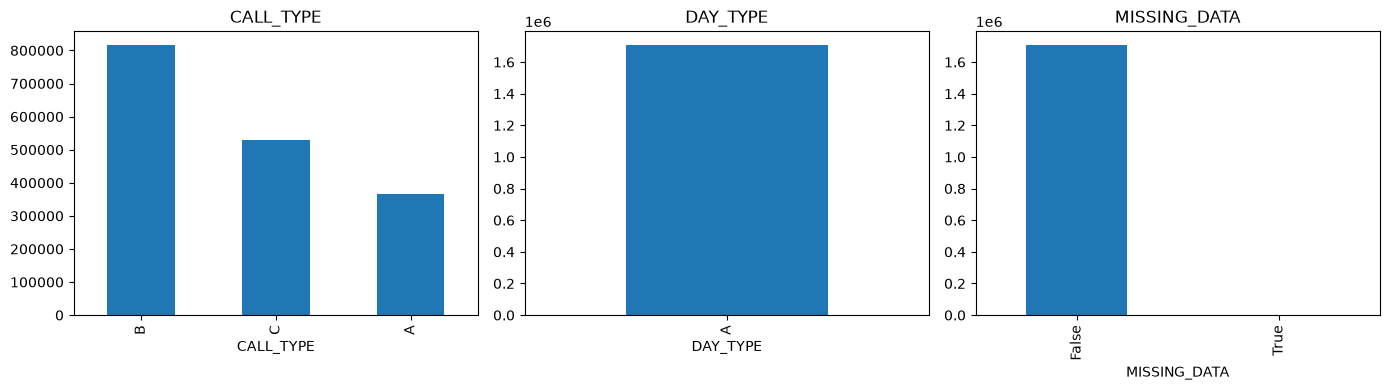

In [56]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(["CALL_TYPE", "DAY_TYPE", "MISSING_DATA"]):
    counts = df[col].value_counts()
    print(counts, "\n")
    counts.plot(kind="bar", ax=ax[i], title=col)
plt.tight_layout(); plt.show()

### Taxier

In [57]:
trips_per_taxi = df["TAXI_ID"].value_counts()
print("Antall taxier:", df["TAXI_ID"].nunique())
print(trips_per_taxi.describe())

Antall taxier: 448
count      448.000000
mean      3818.459821
std       1644.021173
min          1.000000
25%       2694.000000
50%       3732.000000
75%       5023.250000
max      10746.000000
Name: count, dtype: float64


### Tid

Første: 2013-07-01 01:00:53 | Siste: 2014-07-01 00:59:56


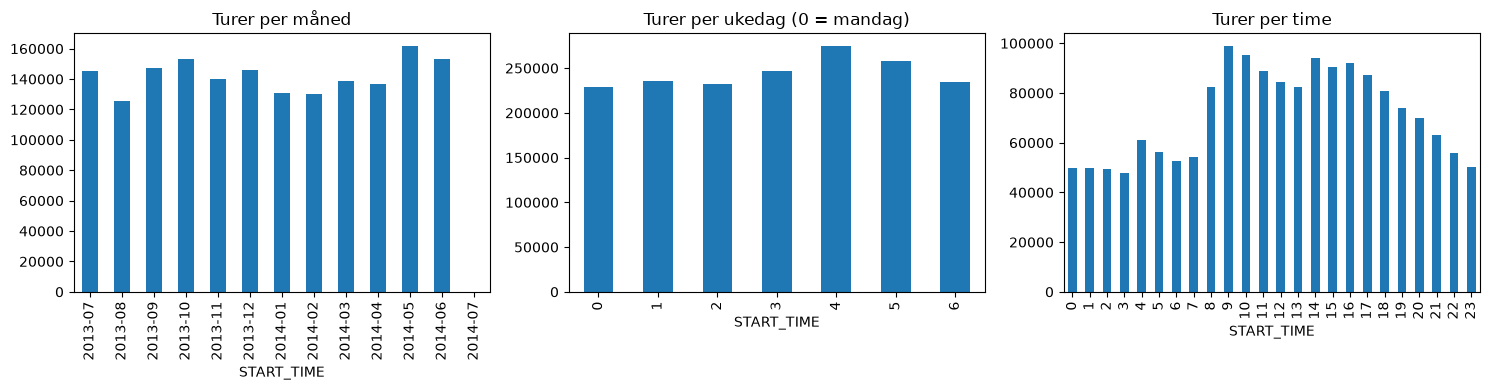

In [58]:
df["START_TIME"] = pd.to_datetime(df["TIMESTAMP"], unit="s", utc=True).dt.tz_convert("Europe/Lisbon").dt.tz_localize(None)
print("Første:", df["START_TIME"].min(), "| Siste:", df["START_TIME"].max())

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df["START_TIME"].dt.to_period("M").value_counts().sort_index().plot(kind="bar", ax=ax[0], title="Turer per måned")
df["START_TIME"].dt.dayofweek.value_counts().sort_index().plot(kind="bar", ax=ax[1], title="Turer per ukedag (0 = mandag)")
df["START_TIME"].dt.hour.value_counts().sort_index().plot(kind="bar", ax=ax[2], title="Turer per time")
plt.tight_layout(); plt.show()

### Antall GPS-punkter og varighet

In [59]:
df["N_POINTS"] = df["POLYLINE"].str.count(r"\[") - 1
df["DURATION_MIN"] = (df["N_POINTS"] - 1).clip(lower=0) * 15 / 60

print(df["N_POINTS"].describe(), "\n")
print("Turer med 0 punkter:        ", (df["N_POINTS"] == 0).sum())
print("Turer med < 3 punkter:      ", (df["N_POINTS"] < 3).sum())
print("Turer lengre enn 2 timer:   ", (df["DURATION_MIN"] > 120).sum())
print("Totalt antall GPS-punkter:  ", df["N_POINTS"].sum())

count    1.710670e+06
mean     4.875831e+01
std      4.565372e+01
min      0.000000e+00
25%      2.800000e+01
50%      4.100000e+01
75%      5.900000e+01
max      3.881000e+03
Name: N_POINTS, dtype: float64 

Turer med 0 punkter:         5901
Turer med < 3 punkter:       43904
Turer lengre enn 2 timer:    2257
Totalt antall GPS-punkter:   83409386


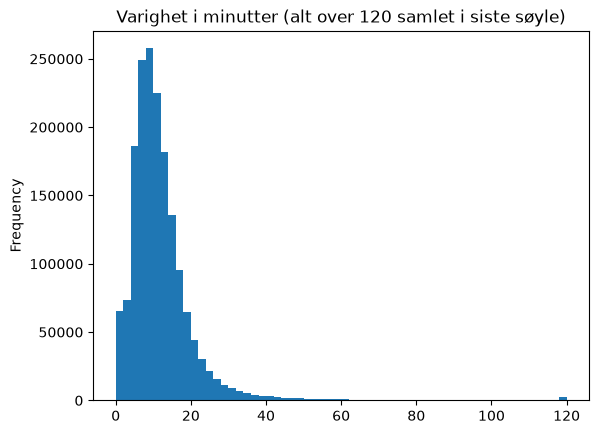

In [60]:
df["DURATION_MIN"].clip(upper=120).plot(kind="hist", bins=60,
    title="Varighet i minutter (alt over 120 samlet i siste søyle)")
plt.show()

### GPS feil

In [61]:
unik = df[(df["N_POINTS"] > 0) & ~df["TRIP_ID"].duplicated(keep=False)]
sample = unik.sample(100_000, random_state=42)

pts = sample[["TRIP_ID", "POLYLINE"]].copy()
pts["POLYLINE"] = pts["POLYLINE"].apply(json.loads)       # tekst -> liste
pts = pts.explode("POLYLINE", ignore_index=True)          # én rad per punkt
pts["lon"] = pts["POLYLINE"].str[0].astype(float)
pts["lat"] = pts["POLYLINE"].str[1].astype(float)
pts = pts.drop(columns="POLYLINE")
print("Turer:", pts["TRIP_ID"].nunique(), "| Punkter:", len(pts))

Turer: 100000 | Punkter: 4871956


In [62]:
def haversine_m(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    a = np.sin((lat2 - lat1) / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2)**2
    return 6_371_000 * 2 * np.arcsin(np.sqrt(a))

prev = pts.groupby("TRIP_ID")[["lon", "lat"]].shift()
pts["step_m"] = haversine_m(prev["lon"], prev["lat"], pts["lon"], pts["lat"])
pts["speed_kmh"] = pts["step_m"] / 15 * 3.6

print(pts["speed_kmh"].describe(percentiles=[0.5, 0.9, 0.99, 0.999]))
for grense in [120, 160, 200, 500]:
    turer = pts.loc[pts["speed_kmh"] > grense, "TRIP_ID"].nunique()
    print(f"Hopp over {grense} km/t: {(pts['speed_kmh'] > grense).sum()} punkter i {turer} turer")

count    4.771956e+06
mean     2.752347e+01
std      3.998360e+01
min      0.000000e+00
50%      2.103676e+01
90%      6.409124e+01
99%      1.179571e+02
99.9%    1.881012e+02
max      2.548941e+04
Name: speed_kmh, dtype: float64
Hopp over 120 km/t: 42596 punkter i 14906 turer
Hopp over 160 km/t: 9717 punkter i 8453 turer
Hopp over 200 km/t: 2696 punkter i 2206 turer
Hopp over 500 km/t: 684 punkter i 500 turer


In [63]:
pts["hopp"] = pts["speed_kmh"] > 200

per_tur = pts.groupby("TRIP_ID").agg(
    n_punkter=("lon", "size"),
    distanse_km=("step_m", "sum"),
    maks_fart=("speed_kmh", "max"),
    har_hopp=("hopp", "any"),
)
per_tur["distanse_km"] /= 1000
per_tur["stillestaende"] = (per_tur["n_punkter"] >= 3) & (per_tur["distanse_km"] < 0.1)

antall = len(per_tur)
for kol in ["har_hopp", "stillestaende"]:
    n = per_tur[kol].sum()
    print(f"{kol:15} {n:6} turer ({n/antall:.2%}) -> ca. {n/antall*len(df):,.0f} i hele datasettet")

print(per_tur[per_tur["stillestaende"]]["n_punkter"].describe())

har_hopp          2206 turer (2.21%) -> ca. 37,737 i hele datasettet
stillestaende      495 turer (0.50%) -> ca. 8,468 i hele datasettet
count    495.000000
mean      10.907071
std       11.205454
min        3.000000
25%        4.000000
50%        6.000000
75%       15.000000
max       85.000000
Name: n_punkter, dtype: float64


       DURATION_MIN      DIST_KM  SNITTFART_KMH
count   2257.000000  2257.000000    2257.000000
mean     192.539433    82.951100      25.418439
std       94.489244    95.038723      25.502249
min      120.250000     0.442450       0.143497
25%      136.750000    19.836495       7.163391
50%      159.250000    42.024803      14.705576
75%      209.250000   119.401136      35.100283
max      970.000000   751.592221     152.066075
Andel med snittfart under 10 km/t: 37.2%


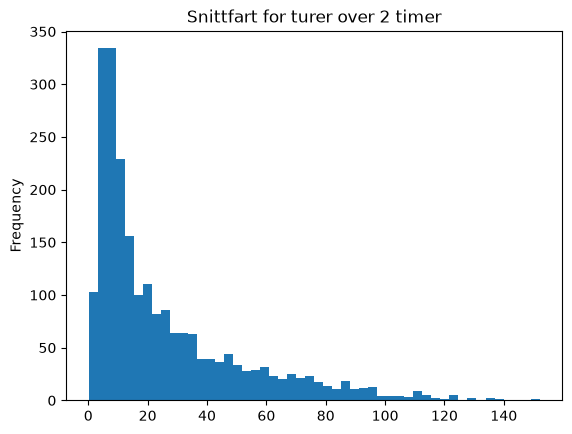

In [65]:
lange = df[df["DURATION_MIN"] > 120].copy()

def tur_distanse_km(polyline):
    c = np.array(json.loads(polyline))
    if len(c) < 2:
        return 0.0
    steg = haversine_m(c[:-1, 0], c[:-1, 1], c[1:, 0], c[1:, 1])
    return steg[steg <= 833].sum() / 1000     # samme GPS-hopp-regel som i innsettingen

lange["DIST_KM"] = lange["POLYLINE"].apply(tur_distanse_km)
lange["SNITTFART_KMH"] = lange["DIST_KM"] / (lange["DURATION_MIN"] / 60)

print(lange[["DURATION_MIN", "DIST_KM", "SNITTFART_KMH"]].describe())
print("Andel med snittfart under 10 km/t:", f"{(lange['SNITTFART_KMH'] < 10).mean():.1%}")
lange["SNITTFART_KMH"].plot(kind="hist", bins=50, title="Snittfart for turer over 2 timer")
plt.show()

### Missing data

In [66]:
missing = df[df["MISSING_DATA"] == True]
print("Antall rader:", len(missing))
missing[["TRIP_ID", "TAXI_ID", "POLYLINE"]]


Antall rader: 10


,TRIP_ID,TAXI_ID,POLYLINE
105621,1374554455620000625,20000625,"[[-8.612559,41.145975],[-8.612577,41.145975],[..."
171397,1375863510620000454,20000454,"[[-0.205893,41.010282]]"
299137,1378544246620000057,20000057,"[[-8.569719,41.166135],[-8.567928,41.166477],[..."
457486,1381233613620000387,20000387,"[[-8.626347,41.153436],[-8.626275,41.152905],[..."
738466,1386346894620000904,20000904,"[[-8.652816,40.636575],[-8.652807,40.636566],[..."
782321,1387137779620000640,20000640,"[[-8.604558,41.161941],[-8.604477,41.162013],[..."
848552,1388351478620000678,20000678,"[[-8.609697,41.160276],[-8.609571,41.16033],[-..."
932391,1390005983620000640,20000640,"[[-8.604792,41.16123],[-8.604801,41.161167],[-..."
1275934,1396631707620000163,20000163,"[[-10.634022,43.834248]]"
1432196,1399405185620000508,20000508,"[[-8.620011,41.14683],[-8.619957,41.146659],[-..."


### Funn og beslutninger

| Funn | Beslutning |
|---|---|
| DAY_TYPE har kun verdien A, selv om perioden inneholder helligdager | Kolonnen fjernes |
| 10 rader har MISSING_DATA = True | Radene fjernes, så fjernes MISSING_DATA-kolonnen |
| 80 TRIP_ID-er er duplisert (161 rader, inkl. 3 helt like rader). Samme taxi og tidspunkt, men ulik POLYLINE/CALL_TYPE | Alle 161 radene fjernes, siden det ikke kan avgjøres hvilken versjon som er riktig. TRIP_ID blir da unik og brukes som primærnøkkel |
| 11 302 turer med CALL_TYPE B mangler ORIGIN_STAND | Turene beholdes, og ORIGIN_STAND lagres som NULL |
| TRIP_ID er et 19-sifret tall | Lagres som BIGINT |
| ORIGIN_CALL og ORIGIN_STAND er float pga. NaN | Lagres som INT som tillater NULL |
| TIMESTAMP er Unix-tid (sekunder siden 01.01.1970, UTC) | Konverteres til DATETIME i lokal Porto-tid (Europe/Lisbon, tar hensyn til sommertid) |
| 5 901 turer har 0 GPS-punkter, 43 904 har færre enn 3 | Beholdes i databasen?|
| 2 257 turer varer over 2 timer (maks ca. 16 t). 37,2 % av dem har snittfart under 10 km/t, mens en fjerdedel har over 35 km/t | Turer over 2 timer med snittfart under 10 km/t regnes som glemt taxameter og fjernes. Lange turer med høyere snittfart er ekte langturer og beholdes |
| Ca. 2,2 % av turene har minst ett GPS-hopp over 200 km/t, oftest ett enkelt feilpunkt i en ellers gyldig tur | Turene beholdes?|
| Ca. 0,5 % av turene er stillestående (minst 3 punkter, under 100 m total distanse) | Beholdes?|
| 448 taxier, i snitt ca. 3 800 turer per taxi; noen få har svært få turer | Trenger ikke gjøre noe |
| Perioden er 01.07.2013–30.06.2014 som forventet; mest trafikk på fredager og kl. 8–9 | Trenger ikke gjøre noe |